# Team 
Guilherme F. C. Marin and Sharan

# Gradient-Based Feature Attribution Exercise

In this exercise, you will implement the three **Gradient-Based**, feature attribution methods introduced in the lecture:
* **Vanilla Gradients**
* **Integrated Gradients**
* **Expected Gradients**

## Setup and Imports

The exercise was tested with python 3.11
Either create a new virtualenvironment form requirements_gradients.txt or add captum to the venv of the shap exercise.

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from captum.attr import IntegratedGradients

device = torch.device("cpu")
print(f"Using device: {device}")

c:\Users\USER\Desktop\THI\05-SummerSemester\HCIandExplainableAI\XAI-HCI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Load pre-trained VGG16
model = models.vgg16(weights="IMAGENET1K_V1")
model.eval()
model = model.to(device)

# Load ImageNet class names
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
class_names = [line.strip() for line in response.text.split('\n')]
print(f"Model loaded. {len(class_names)} classes.")

Model loaded. 1000 classes.


In [3]:
data_path = Path("../Data")

def load_image(img_name, target_size=(224, 224)):
    """Load an image and return PIL image"""
    img_path = data_path / img_name
    
    if not img_path.exists():
        print(f"Warning: {img_path} not found. Using a placeholder.")
        arr = np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)
        for i in range(target_size[0]):
            arr[i, :, :] = [100 + i//4, 150, 200]
        img = Image.fromarray(arr)
    else:
        img = Image.open(img_path).convert('RGB')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
    
    return img

test_image_name = "poodle.png"

## Preprocessing and Model Prediction

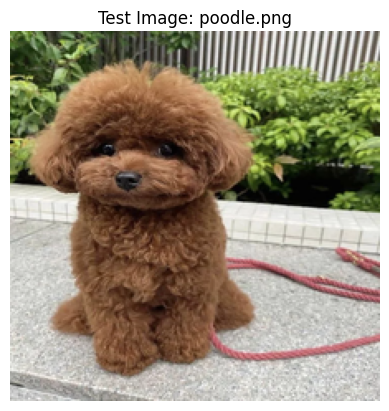

In [4]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

def denormalize(tensor):
    """Convert normalized tensor to displayable image"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)


original_img = load_image(test_image_name)
img_array = np.array(original_img)

plt.imshow(original_img)
plt.title(f"Test Image: {test_image_name}")
plt.axis('off')
plt.show()

In [5]:
img_tensor = preprocess(original_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(img_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    predicted_class = torch.argmax(probabilities).item()
    predicted_prob = probabilities[predicted_class].item()
    top5 = torch.argsort(probabilities, descending=True)[:5]
    

predicted_class = top5[0].item()
print(f"\nPredicted: {class_names[predicted_class]} ({probabilities[predicted_class]:.3f})")
print("\nTop 5 predictions:")
for i, idx in enumerate(top5):
    print(f"  {i+1}. {class_names[idx]}: {probabilities[idx]:.3f}")


Predicted: toy poodle (0.770)

Top 5 predictions:
  1. toy poodle: 0.770
  2. miniature poodle: 0.229
  3. standard poodle: 0.001
  4. teddy: 0.000
  5. Blenheim spaniel: 0.000


## **Helper Function to Visualize Attribution Maps**

In [6]:
def visualize_attributions(original_img, attributions, title, cmap='viridis'):
    """
    Visualize feature attribution scores for an image as a heatmap and overlay.

    Converts attribution values to a 2D  heatmap by summing the absolute
    attribution magnitudes across channels, normalizes the map using the 95th
    percentile to reduce the effect of extreme values, and displays three plots:
    the original image, the normalized attribution heatmap, and the heatmap
    overlaid on the original image.

    Args:
        original_img: The original image to display. Should be compatible with
            `matplotlib.pyplot.imshow`, such as a NumPy array or PIL image.
        attributions: Attribution tensor with shape `(1, C, H, W)`. 
            The batch dimension is squeezed, and attribution values
             are converted to a NumPy array before visualization.
        title: Title text used for the attribution heatmap plot.
        cmap: Matplotlib colormap used for the heatmap.
    """
    attr_np = attributions.squeeze(0).detach().cpu().numpy()
    attr_map = np.sum(np.abs(attr_np), axis=0)
    vmax = np.percentile(attr_map, 95)
    attr_map_norm = attr_map / (vmax + 1e-8)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Heatmap only
    im = axes[1].imshow(attr_map_norm, cmap=cmap)
    axes[1].set_title(f'{title}\nAttribution Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(original_img)
    axes[2].imshow(attr_map_norm, cmap=cmap, alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## ** Exercise 1: Implementing Vanilla Gradients**

Complete the following function with your own implementation of vanilla gradients (see the gradient slides for the formula).

Reminder for helpful functions:
* https://docs.pytorch.org/docs/stable/generated/torch.Tensor.backward.html
* https://docs.pytorch.org/docs/stable/generated/torch.Tensor.requires_grad_.html


In [ ]:
def vanilla_gradients(model, input_tensor, target_class):
    # TODO your code here
    
    model.eval()
    input_tensor.requires_grad = True
    model.zero_grad()
    output = model(input_tensor)
    
    target_score = output[0, target_class]
    target_score.backward()
    
    gradient = input_tensor.grad.data
    
    return gradient


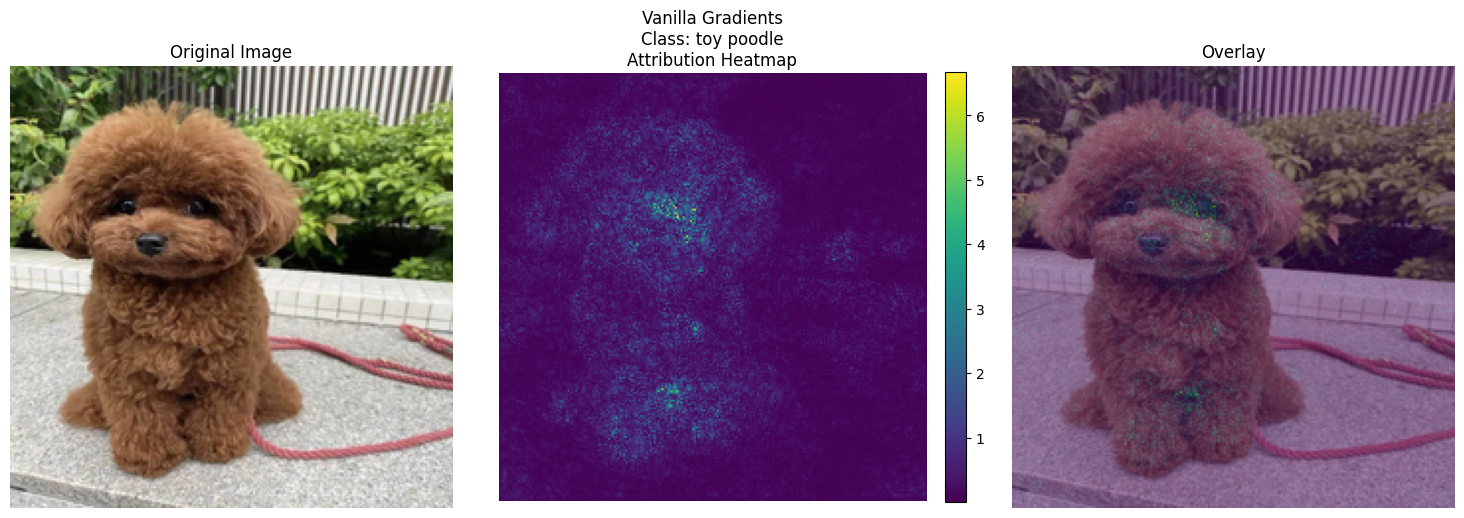

In [9]:
original_img = load_image(test_image_name)
img_tensor = preprocess(original_img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

gradient_attributions =vanilla_gradients(model=model, input_tensor=img_tensor, target_class=predicted_class)

visualize_attributions(
    original_img,
    gradient_attributions,
    f"Vanilla Gradients\nClass: {class_names[predicted_class]}"
)

## **Exercise 2: Integrated Gradients**

Use the Integrated Gradients implementation of Captum to analyze the test image.
Use a black image as reference. Do not forget to normalize the reference image according to the Imagenet preprocessing to stay in distribution.

References: 
* [Captum Documentation: Integrated Gradients](https://captum.ai/docs/extension/integrated_gradients)
* https://captum.ai/api/integrated_gradients.html

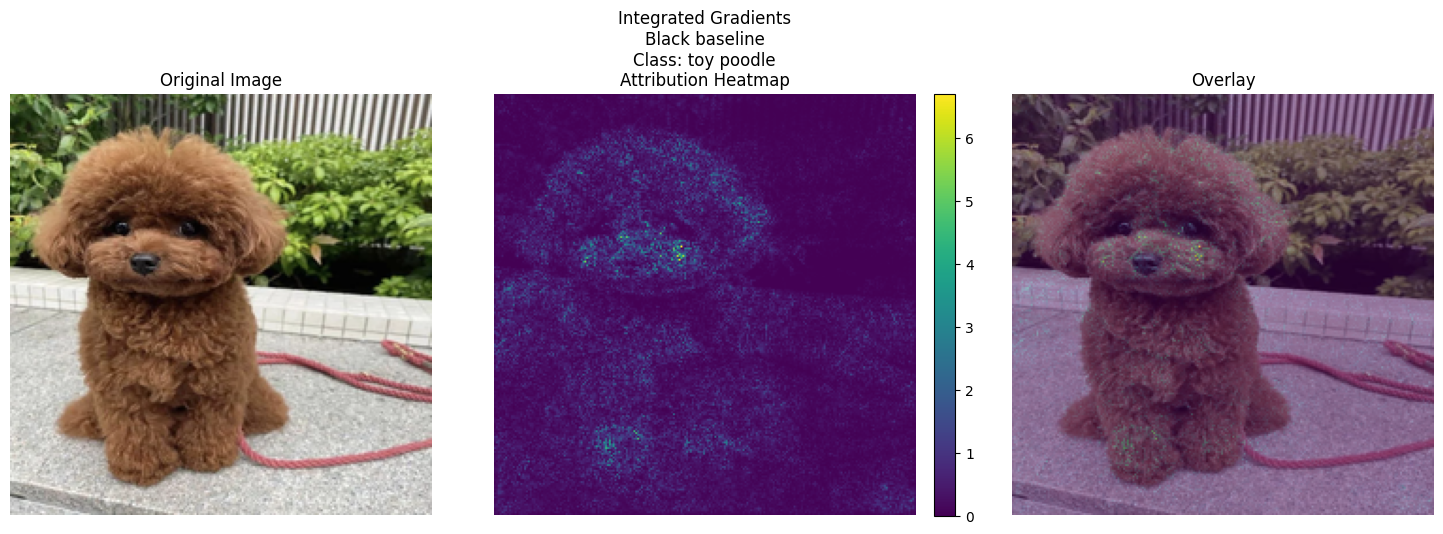

In [ ]:
black_baseline = preprocess(Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))).unsqueeze(0).to(device)

ig = IntegratedGradients(model)

integrated_gradients_attr = ig.attribute(
    img_tensor,
    baselines=black_baseline,
    target=predicted_class,
    n_steps=50,
    internal_batch_size=1
)

visualize_attributions(
    original_img,
    integrated_gradients_attr,
    f"Integrated Gradients\nBlack baseline\nClass: {class_names[predicted_class]}"
)

## ** Experiment with Different Baselines**

Now use an additional white image and random pixel image as reference and compare the results.

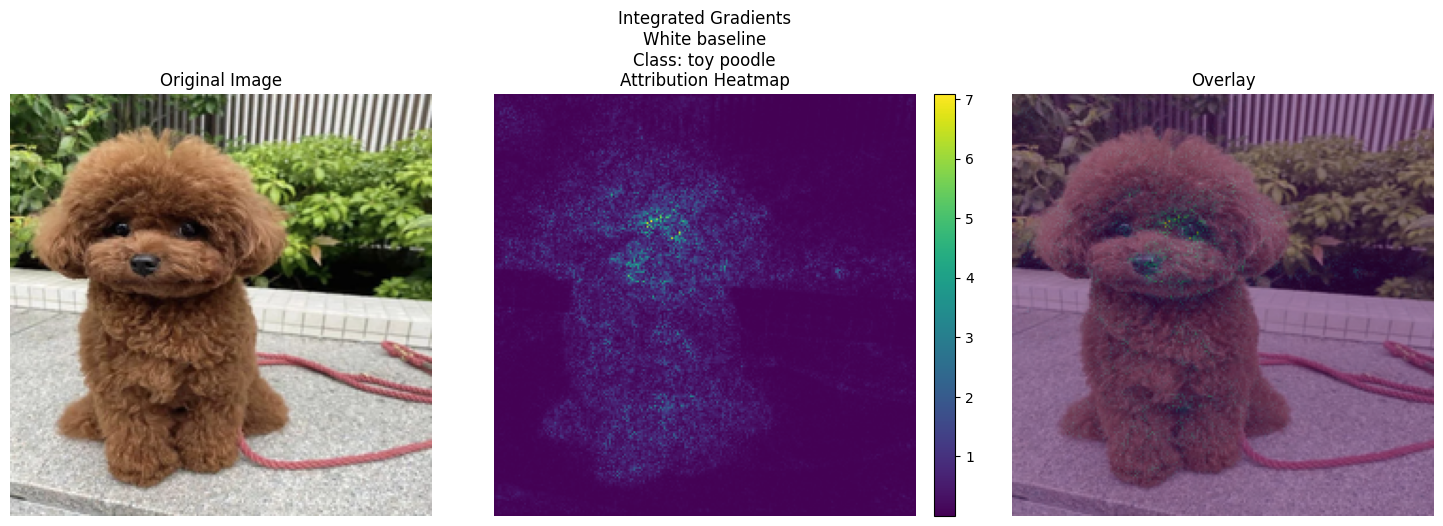

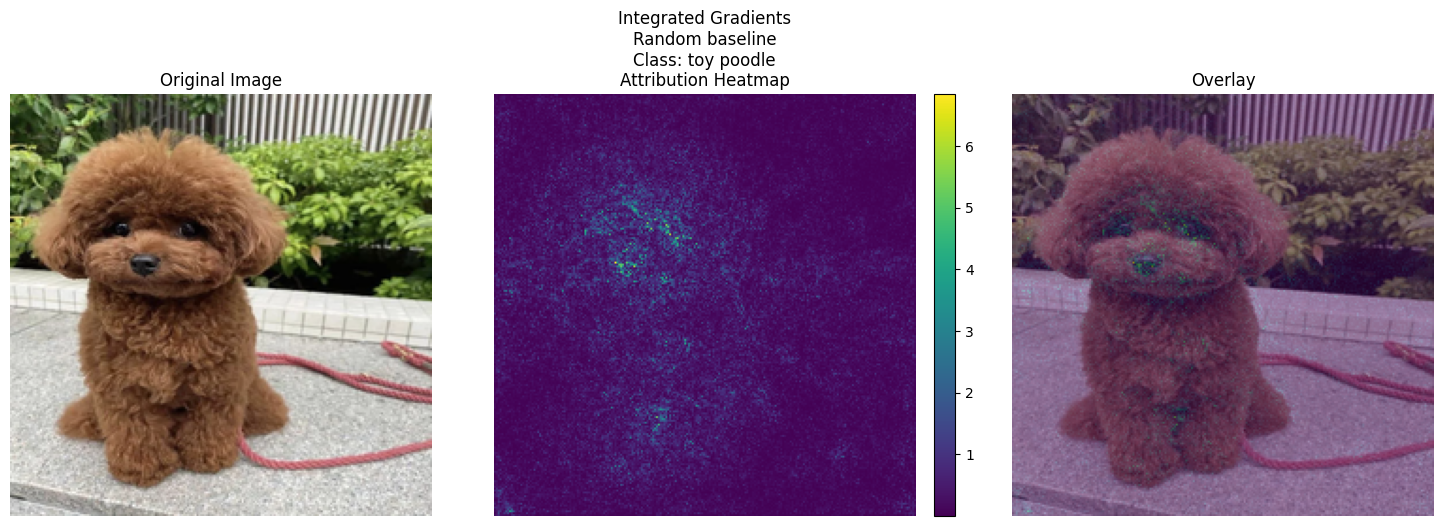

In [8]:
white_baseline = preprocess(Image.fromarray(np.ones((224, 224, 3), dtype=np.uint8) * 255)).unsqueeze(0).to(device)
random_baseline = preprocess(Image.fromarray(np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8))).unsqueeze(0).to(device)

for baseline_name, baseline in [
    ("White", white_baseline),
    ("Random", random_baseline)
]:
    attr = ig.attribute(
        img_tensor,
        baselines=baseline,
        target=predicted_class,
        n_steps=50,
        internal_batch_size=1
    )
    visualize_attributions(
        original_img,
        attr,
        f"Integrated Gradients\n{baseline_name} baseline\nClass: {class_names[predicted_class]}"
    )

** Exercise 3: Expected Gradients **

Finally, use the Shap GradientExplainer to implement ExpectedGradients.

To this end, I uploaded an imagenet-sample.7z which contains 1000 images from Imagenet. Please unpack it in the same Data folder which you used for the test image.

Reference:
* https://shap.readthedocs.io/en/latest/generated/shap.GradientExplainer.html


Computing GradientSHAP values


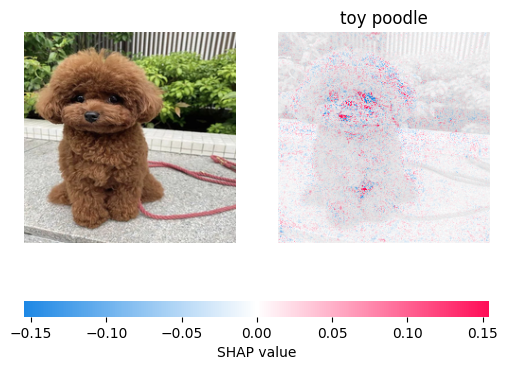

In [27]:
import shap

folder = Path("../Data/imagenet-sample/data")
image_paths = [str(p) for p in folder.iterdir() if p.is_file()]

# TODO your code here